# Edward Moswane Assignment 9: Unsupervised Learning

In [ ]:
# Importing significant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D

print("Libraries imported successfully!")

Libraries imported successfully!


# Dataset Selection and Preprocessing

In [ ]:
# Loading the Mall Customers dataset

url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df = pd.read_csv(url)

# show first and last rows
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
# Show the shape of the dataset
print("Dataset shape:", df.shape)

# show attribute
print("\nData types:")
print(df.dtypes)

# Show basic statistics
print("\nDescriptive statistics:")
display(df.describe())

Dataset shape: (200, 5)

Data types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Descriptive statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Checking Missing Values and Duplicates

In [ ]:
# Checking for missing values
print("Missing values:")
display(df.isnull().sum())

# Removing duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0



Duplicate rows: 0


In [ ]:
# Removing duplicate rows if any exist
df = df.drop_duplicates()

print("shape of dataset after removing duplicates:", df.shape)

shape of dataset after removing duplicates: (200, 5)


Explore the Features

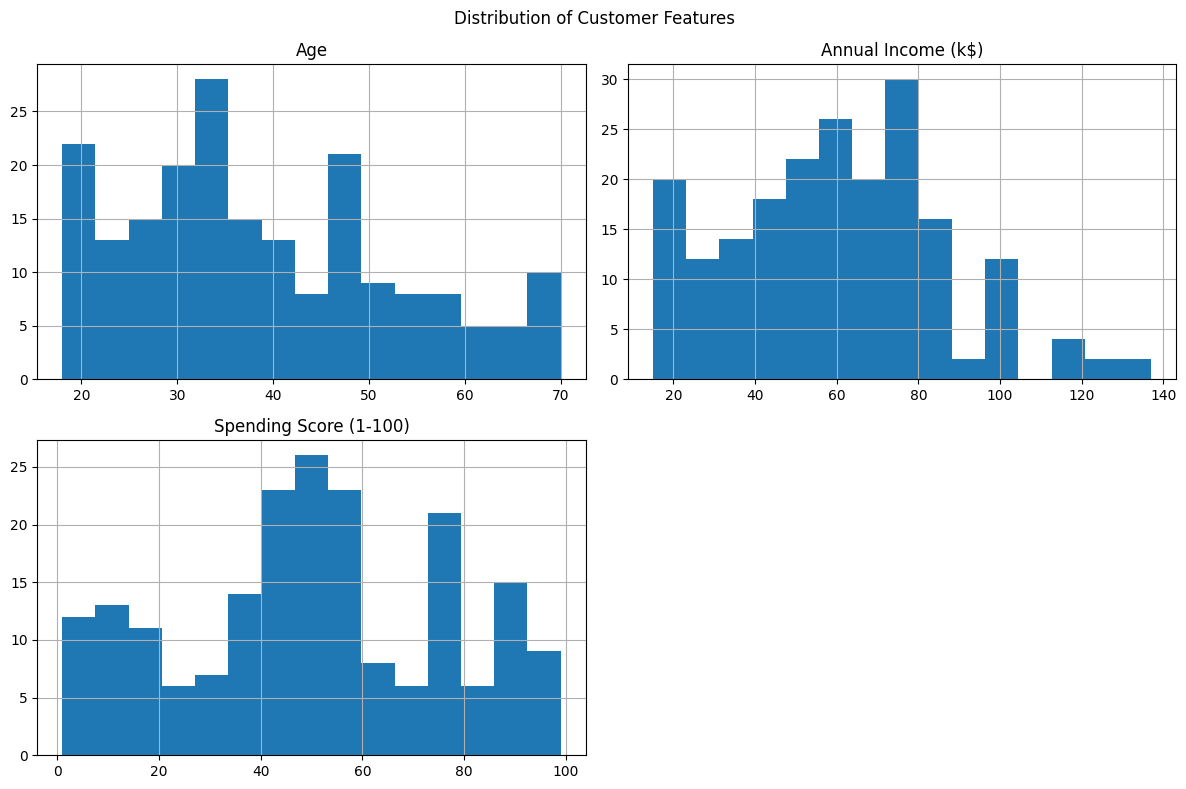

In [ ]:
# Selecting numerical features for analysis
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Feautures distributions
df[features].hist(figsize=(12, 8), bins=15)

plt.suptitle("Distribution of Customer Features")
plt.tight_layout()
plt.show()

Correlation Heatmap

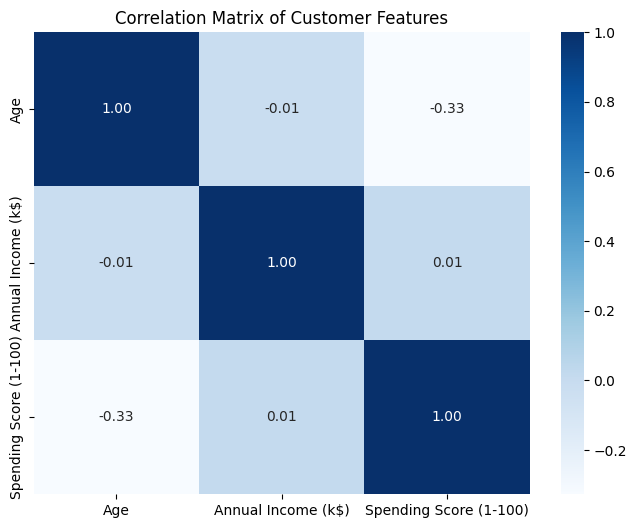

In [ ]:
# Creating a correlation matrix plt
correlation_matrix = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix,annot=True,cmap="Blues",fmt=".2f")

plt.title("Correlation Matrix of Customer Features")
plt.show()

Prepare the Data Clustering

In [ ]:
# Selecting features for clustering
X = df[features].copy()

# Standardization the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

display(X_scaled_df.head())

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


K-Means-Clusters

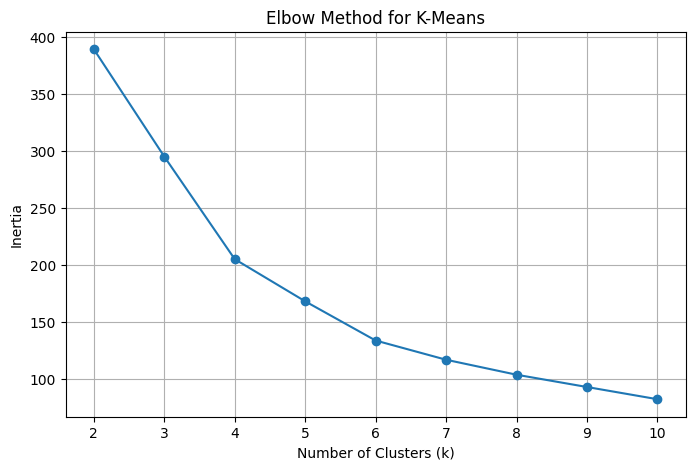

In [ ]:
# Calculating inertia for different numbers of clusters

inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(k_values)
plt.grid(True)
plt.show()

K-Means Silhouette Scores

In [ ]:
silhouette_scores_kmeans = []

for k in k_values:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)

    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores_kmeans.append(score)

# Show scores
silhouette_results = pd.DataFrame({"Number of Clusters": list(k_values),"Silhouette Score": silhouette_scores_kmeans})
display(silhouette_results)

,Number of Clusters,Silhouette Score
0,2,0.335472
1,3,0.357793
2,4,0.403958
3,5,0.416643
4,6,0.428417
5,7,0.417232
6,8,0.408207
7,9,0.417693
8,10,0.406554


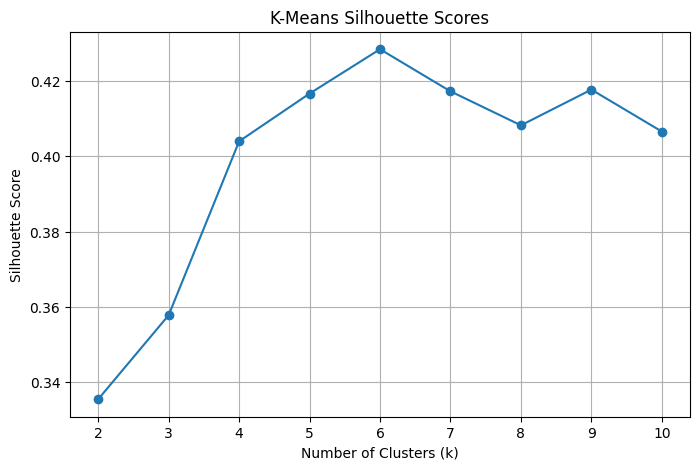

In [ ]:
# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_values,silhouette_scores_kmeans,marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Scores")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
# Identifying the best k
best_k_kmeans = k_values[np.argmax(silhouette_scores_kmeans)]

print("Best K-Means number of clusters:", best_k_kmeans)
print("Best K-Means silhouette score:",round(max(silhouette_scores_kmeans), 4))

Best K-Means number of clusters: 6
Best K-Means silhouette score: 0.4284


Final K-Means Model

In [ ]:
# Training the final K-Means model using the best number of clusters

kmeans_final = KMeans(n_clusters=best_k_kmeans,random_state=42,n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Adding cluster labels to the dataset
df["KMeans_Cluster"] = kmeans_labels

print("_____________________K-Means clustering completed______________________.")
df

_____________________K-Means clustering completed______________________.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,5
3,4,Female,23,16,77,4
4,5,Female,31,17,40,5
...,...,...,...,...,...,...
195,196,Female,35,120,79,3
196,197,Female,45,126,28,2
197,198,Male,32,126,74,3
198,199,Male,32,137,18,2


Visualize K-Means Clusters

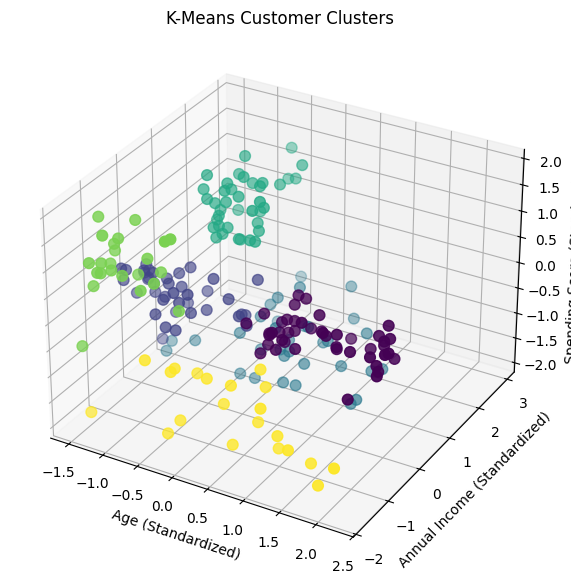

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    X_scaled[:, 2],
    c=kmeans_labels,
    s=60)

ax.set_xlabel("Age (Standardized)")
ax.set_ylabel("Annual Income (Standardized)")
ax.set_zlabel("Spending Score (Standardized)")
ax.set_title("K-Means Customer Clusters")

plt.show()

Hierarchical Clustering

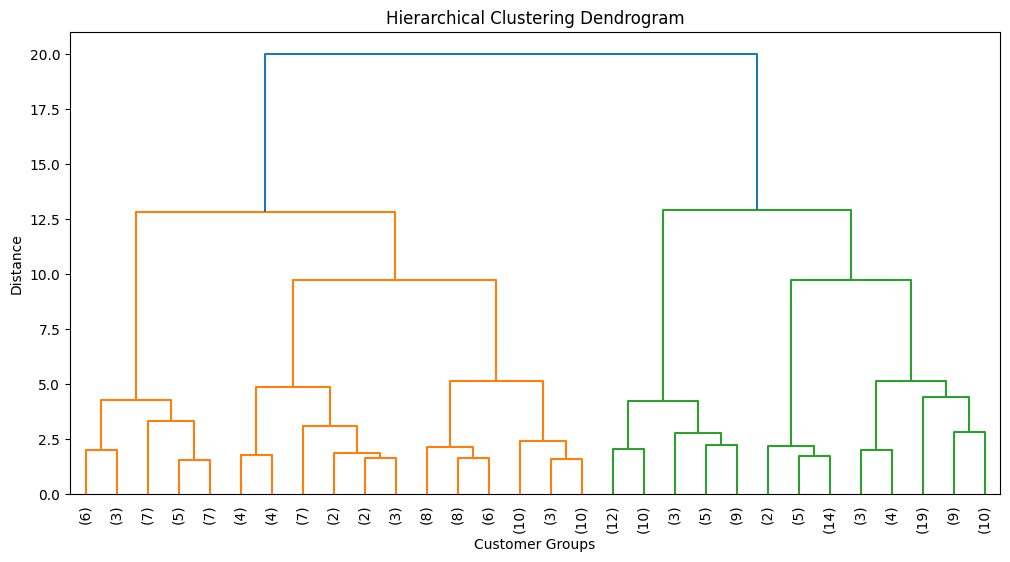

In [ ]:
# Creating linkage matrix
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,truncate_mode='lastp',p=30,leaf_rotation=90,leaf_font_size=10)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Groups")
plt.ylabel("Distance")
plt.show()

Find Optimal Hierarchical Clusters

In [ ]:
# Testing different numbers of clusters for hierarchical clustering

silhouette_scores_hierarchical = []

for k in k_values:
    hierarchical = AgglomerativeClustering(n_clusters=k,linkage='ward')

    labels = hierarchical.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores_hierarchical.append(score)

# Show results
hierarchical_results = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Silhouette Score": silhouette_scores_hierarchical})

display(hierarchical_results)

,Number of Clusters,Silhouette Score
0,2,0.317957
1,3,0.321489
2,4,0.361451
3,5,0.390028
4,6,0.420117
5,7,0.398295
6,8,0.366479
7,9,0.375385
8,10,0.380889


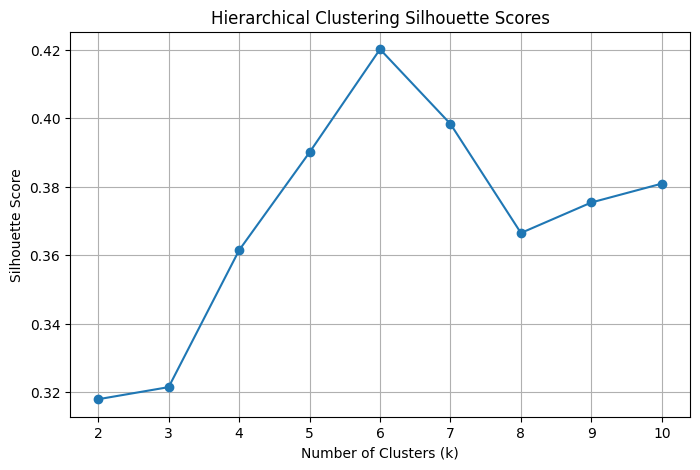

In [ ]:
# Plot silhouette scores
plt.figure(figsize=(8, 5))

plt.plot(k_values,silhouette_scores_hierarchical,marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering Silhouette Scores")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [ ]:
# Identify best k
best_k_hierarchical = k_values[np.argmax(silhouette_scores_hierarchical)]

print("Best Hierarchical number of clusters:",best_k_hierarchical)
print("Best Hierarchical silhouette score:",round(max(silhouette_scores_hierarchical), 4))

Best Hierarchical number of clusters: 6
Best Hierarchical silhouette score: 0.4201


Final Hierarchical Model

In [ ]:
# Train the final hierarchical clustering model

hierarchical_final = AgglomerativeClustering(n_clusters=best_k_hierarchical,linkage='ward')
hierarchical_labels = hierarchical_final.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = hierarchical_labels

print("Hierarchical clustering completed.")

df

Hierarchical clustering completed.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Hierarchical_Cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,4,5
2,3,Female,20,16,6,5,4
3,4,Female,23,16,77,4,5
4,5,Female,31,17,40,5,4
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,3,2
196,197,Female,45,126,28,2,3
197,198,Male,32,126,74,3,2
198,199,Male,32,137,18,2,3


Visualize Hierarchical Clusters

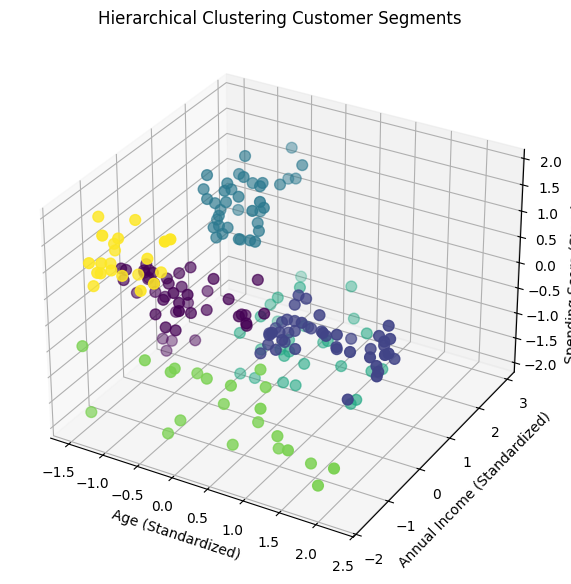

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    X_scaled[:, 2],
    c=hierarchical_labels,s=60)

ax.set_xlabel("Age (Standardized)")
ax.set_ylabel("Annual Income (Standardized)")
ax.set_zlabel("Spending Score (Standardized)")
ax.set_title("Hierarchical Clustering Customer Segments")

plt.show()

Dimensionality Reduction

In [ ]:
# Applying dimentional PCA to reduce the data to two dimensions

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print("\nTotal variance explained:",round(pca.explained_variance_ratio_.sum(), 4))

Explained variance ratio:
[0.44266167 0.33308378]

Total variance explained: 0.7757


PCA Visualization of K-Means

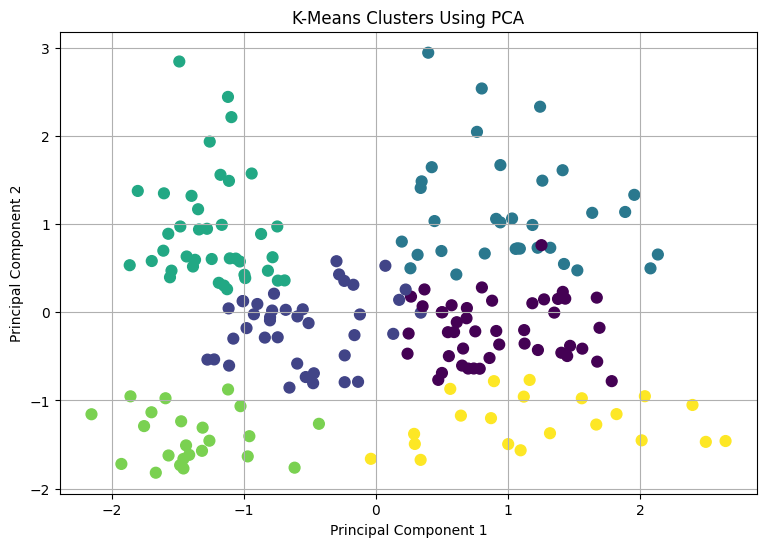

In [ ]:
# Visualizing K-Means clusters using PCA

plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0],X_pca[:, 1],c=kmeans_labels,s=60)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Using PCA")

plt.grid(True)
plt.show()

PCA Visualization of Hierarchical Clustering

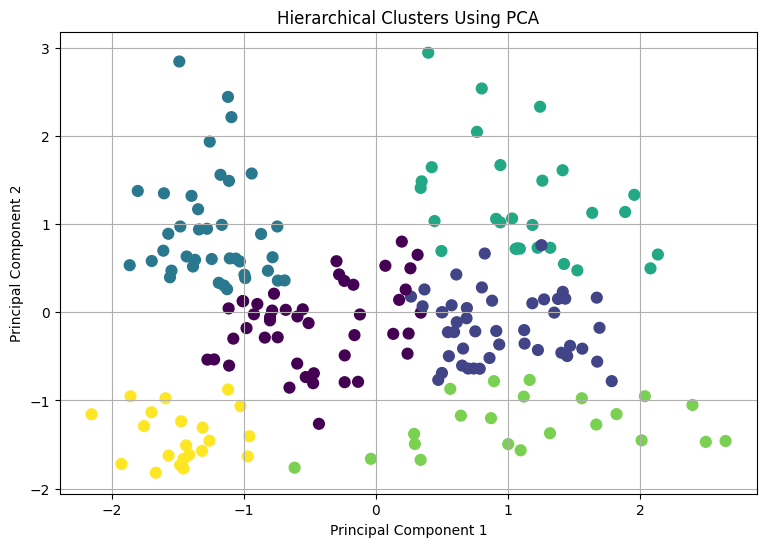

In [ ]:
# Visualize hierarchical clusters using PCA

plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0],X_pca[:, 1],c=hierarchical_labels,s=60)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clusters Using PCA")

plt.grid(True)
plt.show()

Compare the Models

In [ ]:
# Comparing the best silhouette scores from both clustering techniques

comparison = pd.DataFrame({"Clustering Method": ["K-Means","Hierarchical Clustering"],
                           "Optimal Clusters": [best_k_kmeans,best_k_hierarchical],
                           "Silhouette Score": [
        max(silhouette_scores_kmeans),
        max(silhouette_scores_hierarchical)]})

display(comparison)

,Clustering Method,Optimal Clusters,Silhouette Score
0,K-Means,6,0.428417
1,Hierarchical Clustering,6,0.420117


In [ ]:
# Finding the best model
if max(silhouette_scores_kmeans) >= max(silhouette_scores_hierarchical):
    best_model = "K-Means"
    best_score = max(silhouette_scores_kmeans)
else:
    best_model = "Hierarchical Clustering"
    best_score = max(silhouette_scores_hierarchical)

print("Best-performing model:", best_model)
print("Best silhouette score:", round(best_score, 4))

Best-performing model: K-Means
Best silhouette score: 0.4284


Analyze the Customer Segments

In [ ]:
#  Average customer characteristics for each K-Means cluster

cluster_profile = df.groupby("KMeans_Cluster")[features].mean()

display(cluster_profile.round(2))

,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,56.33,54.27,49.07
1,26.79,57.10,48.13
2,41.94,88.94,16.97
3,32.69,86.54,82.13
4,25.00,25.26,77.61
5,45.52,26.29,19.38


In [ ]:
# Display the number of customers in each K-Means cluster

cluster_sizes = df["KMeans_Cluster"].value_counts().sort_index()
print("Number of customers in each K-Means cluster:")

display(cluster_sizes)

Number of customers in each K-Means cluster:


,count
KMeans_Cluster,
0,45
1,39
2,33
3,39
4,23
5,21


# Deployment and Monitoring

**Deployment Strategy**

I suggest K-Means model could be used by a shopping mall to gather customers based on their age, income, address, and purchasing habits. This will help the mall create targeted promotions for various kind of customers. The main challenges would be keeping up with the growing customer data. Data will need to updated as habits change and customers growing.

The model should be checked regularly to make sure the customer data is still accurate and useful. The mall has to monitor changes in customer data either daily, weekly etc, group sizes, and Silhouette Scores, while also checking for missing or incorrect data. If customer spending habit changes significantly, the model can be retrained. New groups should also be compared with the old groups before updating the model.

# Summary and Conclusion

In [ ]:
# Summary of the results
print(f"K-Means optimal clusters: {best_k_kmeans}")
print(f"K-Means silhouette score: {max(silhouette_scores_kmeans):.4f}")

print(f"\nHierarchical optimal clusters: {best_k_hierarchical}")
print(f"Hierarchical silhouette score: {max(silhouette_scores_hierarchical):.4f}")

print(f"\nBest-performing model: {best_model}")
print(f"Best silhouette score: {best_score:.4f}")
print(
    f"\nPCA variance explained by first two components: "
    f"{pca.explained_variance_ratio_.sum():.4f}")

K-Means optimal clusters: 6
K-Means silhouette score: 0.4284

Hierarchical optimal clusters: 6
Hierarchical silhouette score: 0.4201

Best-performing model: K-Means
Best silhouette score: 0.4284

PCA variance explained by first two components: 0.7757


K-Means is the better model because its Silhouette Score (0.4284) is slightly higher than Hierarchical Clustering (0.4201).
A Silhouette Score ~ 0.43 indicates moderately separated clusters. The customer groups have meaningful different insights.
Six clusters was selected as the best number of clusters based on the highest Silhouette Score.
PCA's first two components explain 77.57% of the total variance, meaning the 2D PCA plot preserves a large portion of the information in the original three features.

**In conclusion:**

This assignment covered K-Means and Hierarchical Clustering to group mall customers based on their characteristics. The data was cleaned, explored and standardized before applying the models. The Elbow Method and Silhouette Score were used to evaluate the clusters, and PCA was used to visualize them. The data showed K-Means performed better with a Silhouette Score of 0.4284. Therefore, customer groups could help the mall make smart decision to target customers. However, the model should also be monitored and updated as customer speding behaviour change.

Colab Link

https://colab.research.google.com/drive/13YM3B1plKkIZU1WLC1JUTiMWK5RrzqeJ?usp=sharing